>>> Starting Process...

>>> Checking Folder: C:\Users\User\Documents\FYP\Voice Emotion Dataset
Found 6 emotions: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']



Processing sad: 100%|████████████████████████████████████████████████████████████| 9315/9315 [07:09<00:00, 21.69file/s]



SUCCESS! Loaded 54490 files.
Feature Matrix Shape: (54490, 40, 130)
Saving data...
Data Saved!

Generating Graphs...


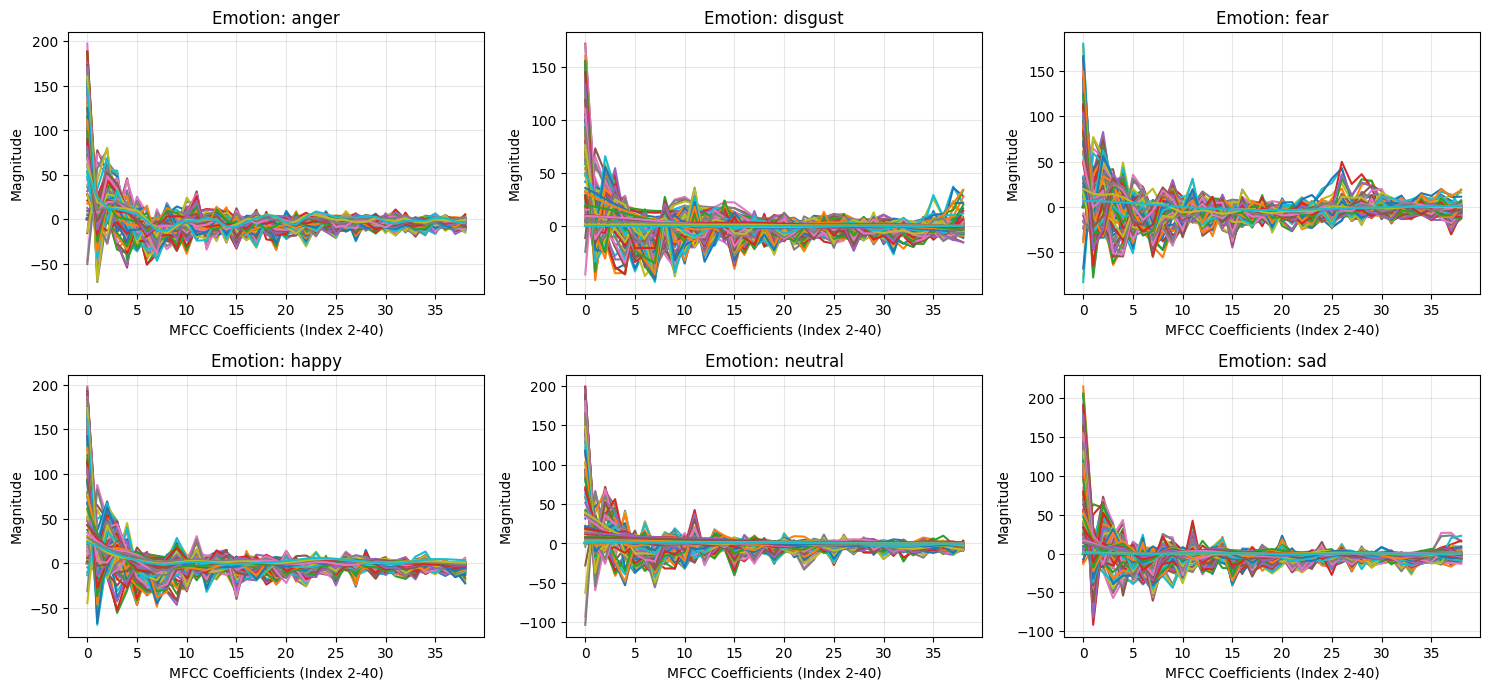

In [2]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_PATH = r"C:\Users\User\Documents\FYP\Voice Emotion Dataset"
SAMPLE_RATE = 22050
DURATION = 3
N_MFCC = 40

def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        target_length = int(SAMPLE_RATE * DURATION)
        
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]
            
        max_val = np.max(np.abs(audio))
        if max_val > 0:
            audio = audio / max_val
            
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        return mfcc
    except Exception as e:
        return None

def load_dataset(path):
    print(f"\n>>> Checking Folder: {path}")
    if not os.path.exists(path):
        print("ERROR: Path not found.")
        return np.array([]), np.array([])
        
    data = []
    labels = []
    
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    print(f"Found {len(folders)} emotions: {folders}\n")

    for folder_name in folders:
        folder_path = os.path.join(path, folder_name)
        all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3'))]
        
        # === THE PROGRESS BAR ===
        # tqdm wraps around 'all_files' and handles the drawing automatically
        for file_name in tqdm(all_files, desc=f"Processing {folder_name}", unit="file"):
            file_path = os.path.join(folder_path, file_name)
            features = extract_features(file_path)
            
            if features is not None:
                data.append(features)
                labels.append(folder_name)
                
    return np.array(data), np.array(labels)

# ==========================================
# 2. EXECUTION
# ==========================================
print(">>> Starting Process...")
X, y = load_dataset(DATASET_PATH)

if len(X) > 0:
    print(f"\nSUCCESS! Loaded {len(X)} files.")
    print(f"Feature Matrix Shape: {X.shape}") 
    
    print("Saving data...")
    np.save("X_features.npy", X)
    np.save("y_labels.npy", y)
    print("Data Saved!")

    # Graphing
    print("\nGenerating Graphs...")
    unique_emotions = np.unique(y)
    plt.figure(figsize=(15, 10))
    
    for i, emotion in enumerate(unique_emotions):
        index = np.where(y == emotion)[0][0]
        plt.subplot(3, 3, i + 1)
        plt.plot(X[index][1:])  # Skip first coefficient
        plt.title(f"Emotion: {emotion}")
        plt.xlabel("MFCC Coefficients (Index 2-40)") 
        plt.ylabel("Magnitude") 
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("No data found.")

C:\Users\User\.conda\envs\ai-env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


>>> Loading processed data...
Classes: ['anger' 'disgust' 'fear' 'happy' 'neutral' 'sad']
Training Shape: (43592, 40, 130, 1)


C:\Users\User\.conda\envs\ai-env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> Hybrid CNN-LSTM Model Built!


Model: "sequential"

...

 Total params: 865,286 (3.30 MB)

 Trainable params: 864,390 (3.30 MB)

 Non-trainable params: 896 (3.50 KB)


>>> Starting Advanced Training...
Epoch 1/70
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 395s 284ms/step - accuracy: 0.3684 - loss: 1.5644 - val_accuracy: 0.5210 - val_loss: 1.2166 - learning_rate: 0.0010
Epoch 2/70
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 336s 247ms/step - accuracy: 0.5442 - loss: 1.1321 - val_accuracy: 0.5807 - val_loss: 1.0679 - learning_rate: 0.0010
Epoch 3/70
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 338s 248ms/step - accuracy: 0.5927 - loss: 1.0357 - val_accuracy: 0.6232 - val_loss: 0.9649 - learning_rate: 0.0010
Epoch 4/70
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 332s 243ms/step - accuracy: 0.6192 - loss: 0.9703 - val_accuracy: 0.6392 - val_loss: 0.9462 - learning_rate: 0.0010
Epoch 5/70
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 338s 248ms/step - accuracy: 0.6520 - loss: 0.9031 - val_accuracy: 0.6475 - val_loss: 0.9022 - learning_rate: 0.0010
Epoch 6/70
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 329s 242ms/step - accuracy: 0.6828 - loss: 0.8383 - val_accuracy: 0.7075 - val_loss: 0.7969 - learning_rate: 0.0010
Epoch 7/70
1363/1


>>> Model saved as 'hybrid_emotion_model.h5'
341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.7771 - loss: 0.6772

Final Test Accuracy: 77.88%


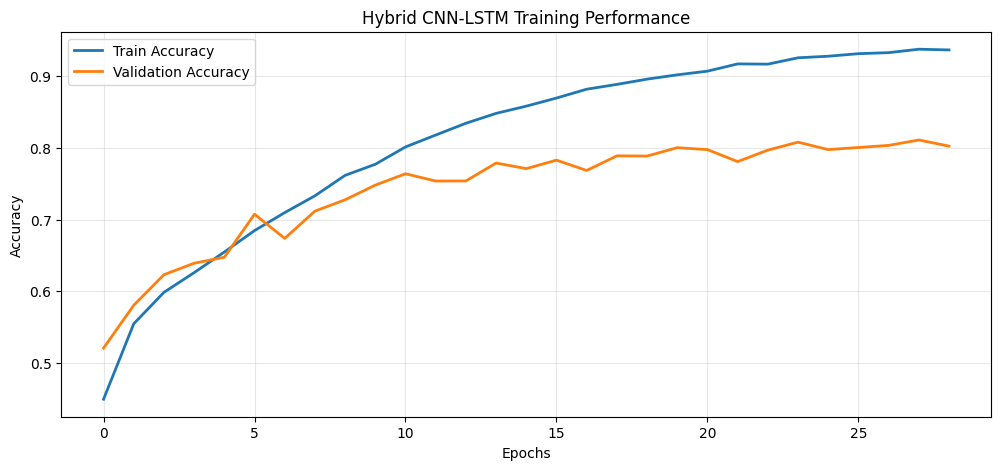

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Reshape, LSTM
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. LOAD DATA
# ==========================================
print(">>> Loading processed data...")
# CRITICAL: This assumes you removed the 'np.mean()' error from your extraction script!
# X should now contain full 2D spectrograms: (Num_Samples, 40_MFCC, Time_Steps)
X = np.load("X_features.npy")
y = np.load("y_labels.npy")

# ==========================================
# 2. PREPARE DATA
# ==========================================
# Encode string labels into one-hot vectors
lb = LabelEncoder()
y_final = to_categorical(lb.fit_transform(y))
classes = lb.classes_
np.save("classes.npy", classes)
print(f"Classes: {classes}")

# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y_final, test_size=0.2, random_state=42)

# Reshape for Conv2D (Batch, Height, Width, Channels)
# We add a '1' at the end to act as a single color channel, like a grayscale image
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"Training Shape: {X_train.shape}")

# Dynamically grab the MFCC bands and Time Steps from your data
n_mfcc = X_train.shape[1]
time_steps = X_train.shape[2]

# ==========================================
# 3. BUILD THE HYBRID CNN-LSTM MODEL
# ==========================================
model = Sequential()

# Block 1: Spatial Feature Extraction (The "Eye")
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(n_mfcc, time_steps, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block 2: Deeper Spatial Features
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block 3: The Transition
# Math to figure out the new grid size after two 2x2 MaxPool layers
new_height = n_mfcc // 4
new_width = time_steps // 4

# Flatten the frequency features, but keep the time steps sequential
model.add(Reshape((new_width, new_height * 128)))

# Block 4: Temporal Memory (The "Brain")
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(64, return_sequences=False))

# Decision Making Layers
model.add(Dense(256, activation='relu')) 
model.add(BatchNormalization())
model.add(Dropout(0.4)) 

# Output Layer
model.add(Dense(len(classes), activation='softmax'))

# Compile
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\n>>> Hybrid CNN-LSTM Model Built!")
model.summary()

# ==========================================
# 4. TRAIN WITH INTELLIGENT CALLBACKS
# ==========================================
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\n>>> Starting Advanced Training...")
history = model.fit(X_train, y_train, 
                    epochs=70, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[lr_scheduler, early_stop], 
                    verbose=1)

# ==========================================
# 5. SAVE & REPORT
# ==========================================
model.save("hybrid_emotion_model.h5") 
print("\n>>> Model saved as 'hybrid_emotion_model.h5'")

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

# Plot the learning curves
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Hybrid CNN-LSTM Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
%%writefile .gitignore
Voice Emotion Dataset/
*.npy
*.h5
__pycache__/

Writing .gitignore


In [3]:
!git init
!git add .
!git commit -m "First save: Voice emotion feature extraction code"
!git branch -M main
!git remote add origin https://github.com/tanhongyu0809/Web-Based-Multi-modal-Emotion-Recognition-and-Analytics-System.git
!git push -u origin main

Reinitialized existing Git repository in C:/Users/User/Documents/Web-Based Multi-modal Emotion Recognition and Analytics System/.git/


[main 6050358] First save: Voice emotion feature extraction code
 4 files changed, 631 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 .gitignore.txt
 create mode 100644 .ipynb_checkpoints/Real FYP-checkpoint.ipynb
 create mode 100644 Real FYP.ipynb


error: remote origin already exists.


branch 'main' set up to track 'origin/main'.


To https://github.com/tanhongyu0809/Web-Based-Multi-modal-Emotion-Recognition-and-Analytics-System.git
   d8e997f..6050358  main -> main
